# Volumes sous-corticaux après JDAC et ses variantes

Ce notebook répond uniquement à trois questions :

1. Les traitements modifient-ils le `run-01` alors qu'il n'y a presque aucun mouvement à corriger ?
2. Les scans bougés se rapprochent-ils du `raw/run-01` du même sujet ?
3. Le volume mesuré reste-t-il associé au score Agitation ?

Toutes les mesures sont des **volumes en mm³** extraits de `aseg.stats`. Le `raw/run-01` est une référence opérationnelle, pas une vérité anatomique parfaite.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
warnings.filterwarnings("ignore")

CONDITIONS = ["brut", "preproc", "jdac", "jdac_antiartonly", "jdac_nodenoise"]
SHORT = {"brut":"brut", "preproc":"prep", "jdac":"jdac",
         "jdac_antiartonly":"aa×1", "jdac_nodenoise":"aa×4"}
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "results/ds004332").exists()), Path.home() / "Documents/GitHub/jdac-motion-correction")
ASEG_DIR = Path.home() / "Documents/derivatives/ds004332/aseg_stats"
ASEG_FILES = {
    "brut": "aseg_brut.csv",
    "preproc": "aseg_preproc.csv",
    "jdac": "aseg_jdac.csv",
    "jdac_antiartonly": "aseg_antiartonly.csv",
    "jdac_nodenoise": "aseg_nodenoise.csv",
}
AGIT = REPO / "results/ds004332/agitation/ds004332_agitation_clinica.csv"

missing = [str(ASEG_DIR / name) for name in ASEG_FILES.values()
           if not (ASEG_DIR / name).is_file()]
if missing:
    raise FileNotFoundError("Tables aseg absentes :\n" + "\n".join(missing))

def load_aseg_table(condition, filename):
    # Les fichiers portent l'extension .csv mais sont séparés par tabulations.
    wide = pd.read_csv(ASEG_DIR / filename, sep="	")
    id_col = "Measure:volume" if "Measure:volume" in wide.columns else wide.columns[0]
    identifiers = wide[id_col].astype(str).str.extract(
        r"(sub-[^_/\s]+)_(run-\d+)", expand=True
    )
    if identifiers.isna().any().any():
        bad = wide.loc[identifiers.isna().any(axis=1), id_col].head().tolist()
        raise ValueError(f"Identifiants sujet/run non reconnus dans {filename}: {bad}")
    long = wide.drop(columns=id_col).assign(
        subject=identifiers[0].values,
        run=identifiers[1].values,
    ).melt(id_vars=["subject", "run"], var_name="measure", value_name="value_mm3")
    long["condition"] = condition
    long["source_file"] = str(ASEG_DIR / filename)
    return long

d = pd.concat(
    [load_aseg_table(condition, filename)
     for condition, filename in ASEG_FILES.items()],
    ignore_index=True,
)
d["value_mm3"] = pd.to_numeric(d["value_mm3"], errors="coerce")
d["condition"] = pd.Categorical(d["condition"], CONDITIONS, ordered=True)
agit = pd.read_csv(AGIT).rename(columns={"sub":"subject", "condition":"run", "motion":"agitation"})
d = d.merge(agit[["subject", "run", "agitation"]], on=["subject", "run"], how="left")
print(f"Dossier source : {ASEG_DIR}")
print(f"{len(d):,} mesures | {d['measure'].nunique()} volumes | {d[['subject','run','condition']].drop_duplicates().shape[0]} acquisitions")

Dossier source : /home/av62870@ens.ad.etsmtl.ca/Documents/derivatives/ds004332/aseg_stats
21,125 mesures | 65 volumes | 325 acquisitions


## 0. Complétude et contrôle des données

Une acquisition n'est analysée que si son `aseg.stats` existe. Les valeurs manquantes, les doublons et l'eTIV sont contrôlés avant les modèles. L'eTIV est conservé comme résultat : une variation de l'eTIV entre conditions peut elle-même révéler une instabilité de reconstruction.

In [2]:
qc = pd.DataFrame({
    "n acquisitions": d.groupby("condition", observed=True).apply(
        lambda x: x[["subject","run"]].drop_duplicates().shape[0]),
    "n mesures": d.groupby("condition", observed=True)["measure"].nunique(),
    "valeurs manquantes": d.groupby("condition", observed=True)["value_mm3"].apply(lambda x: x.isna().sum()),
    "doublons": d.groupby("condition", observed=True).apply(
        lambda x: x.duplicated(["subject","run","measure"]).sum()),
})
display(qc)
etiv = d[d["measure"].isin(["eTIV", "EstimatedTotalIntraCranialVol"])]
if len(etiv):
    display(etiv.groupby(["condition","run"], observed=True)["value_mm3"].agg(["count","mean","std"]))

,n acquisitions,n mesures,valeurs manquantes,doublons
condition,,,,
brut,66,65,0,0
preproc,64,65,0,0
jdac,64,65,0,0
jdac_antiartonly,66,65,0,0
jdac_nodenoise,65,65,0,0


count          mean            std
condition        run                                       
brut             run-01     22  1.646358e+06  165431.095368
                 run-02     22  1.625233e+06  160325.505659
                 run-03     22  1.565963e+06  169739.898858
preproc          run-01     21  1.645934e+06  168813.949623
                 run-02     22  1.621479e+06  155821.911261
                 run-03     21  1.562512e+06  174196.813952
jdac             run-01     22  1.655678e+06  162441.605659
                 run-02     22  1.637787e+06  157878.702382
                 run-03     20  1.588528e+06  182976.682637
jdac_antiartonly run-01     22  1.647074e+06  164047.178786
                 run-02     22  1.628903e+06  157016.754719
                 run-03     22  1.570155e+06  172482.564363
jdac_nodenoise   run-01     21  1.628892e+06  140657.464020
                 run-02     22  1.639626e+06  154340.975109
                 run-03     22  1.588788e+06  173036.375551

## A. Effet propre du traitement sur le scan immobile

Pour chaque structure et chaque sujet :

[
\Delta_{s,c}=V_{s,run01,c}-V_{s,run01,brut}
]

Une différence non nulle indique que le traitement ou la reconstruction FreeSurfer modifie le volume mesuré sur la référence immobile. Les tests sont appariés et les p-values sont corrigées par FDR sur l'ensemble des structures et conditions.

,condition,measure,n,delta_mean_mm3,delta_median_mm3,delta_median_pct,p,p_fdr
122,jdac,WM-hypointensities,22,1375.381818,355.350000,693.435715,9.412766e-04,0.002185
252,jdac_nodenoise,WM-hypointensities,21,520.871429,216.100000,442.541436,8.009911e-03,0.016020
187,jdac_antiartonly,WM-hypointensities,22,844.509091,106.200000,362.779755,8.091927e-04,0.001895
255,jdac_nodenoise,lhSurfaceHoles,21,25.619048,30.000000,218.181818,5.827934e-05,0.000182
250,jdac_nodenoise,SurfaceHoles,21,47.380952,49.000000,206.666667,5.941683e-05,0.000182
259,jdac_nodenoise,rhSurfaceHoles,21,21.761905,20.000000,185.714286,5.827934e-05,0.000182
57,preproc,WM-hypointensities,21,-81.800000,-47.300000,-58.115183,8.009911e-03,0.016020
190,jdac_antiartonly,lhSurfaceHoles,22,9.818182,4.500000,45.000000,1.965155e-04,0.000538
194,jdac_antiartonly,rhSurfaceHoles,22,7.863636,5.500000,43.076923,6.499716e-04,0.001594
185,jdac_antiartonly,SurfaceHoles,22,17.681818,8.500000,36.038961,1.194383e-04,0.000337


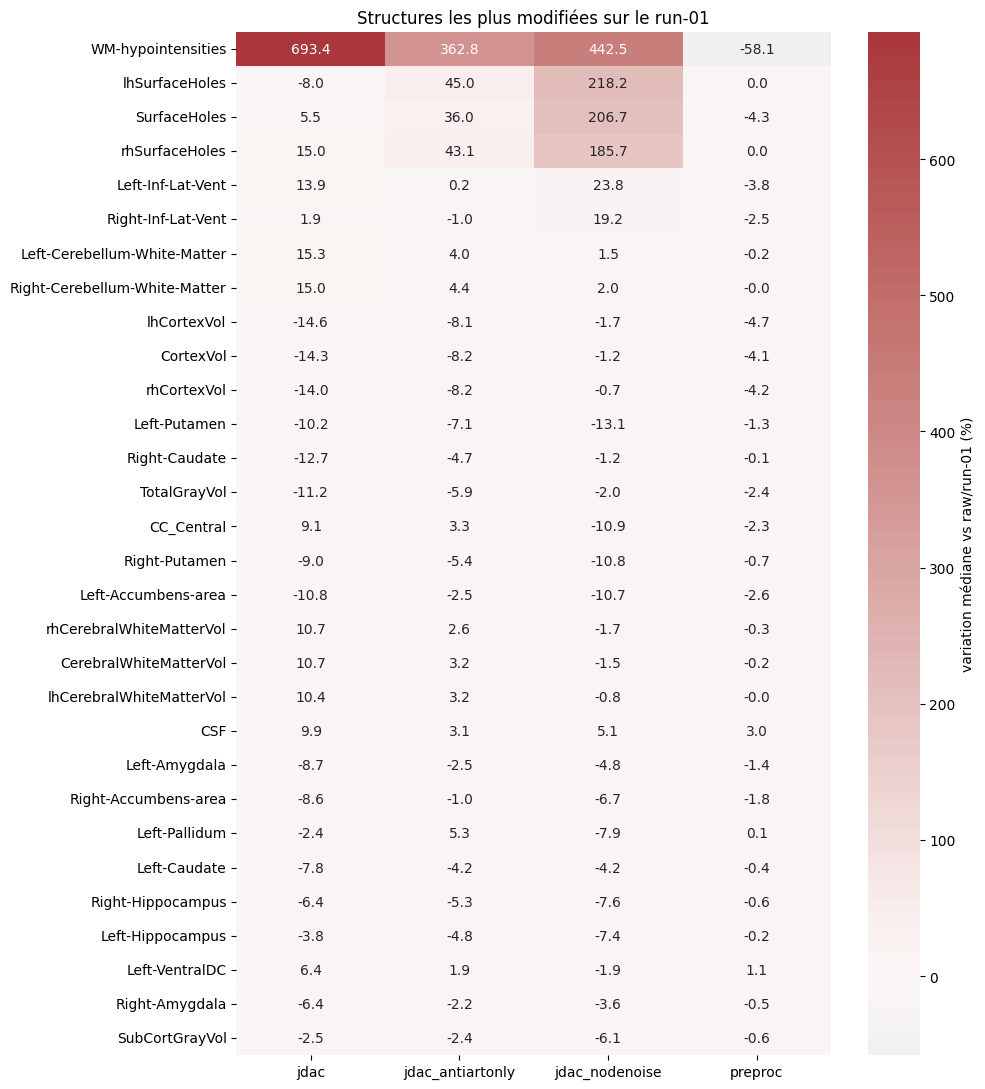

In [3]:
wide01 = d[d["run"]=="run-01"].pivot_table(
    index=["subject","measure"], columns="condition", values="value_mm3", observed=True)
rows = []
for condition in CONDITIONS[1:]:
    pairs = wide01[["brut", condition]].dropna()
    for measure, x in pairs.groupby(level="measure"):
        delta = x[condition] - x["brut"]
        try:
            p = stats.wilcoxon(delta).pvalue if len(delta) >= 3 and np.any(delta != 0) else 1.0
        except ValueError:
            p = np.nan
        rows.append({"condition":condition, "measure":measure, "n":len(delta),
                     "delta_mean_mm3":delta.mean(), "delta_median_mm3":delta.median(),
                     "delta_median_pct":100*np.median(delta/x["brut"]), "p":p})
a = pd.DataFrame(rows)
valid = a["p"].notna()
a.loc[valid, "p_fdr"] = multipletests(a.loc[valid, "p"], method="fdr_bh")[1]
display(a.sort_values("delta_median_pct", key=abs, ascending=False).head(25))

heat = a.pivot(index="measure", columns="condition", values="delta_median_pct")
top = heat.abs().max(axis=1).nlargest(30).index
plt.figure(figsize=(10, 11))
sns.heatmap(heat.loc[top], center=0, cmap="vlag", annot=True, fmt=".1f",
            cbar_kws={"label":"variation médiane vs raw/run-01 (%)"})
plt.title("Structures les plus modifiées sur le run-01")
plt.xlabel(""); plt.ylabel("")
plt.tight_layout(); plt.show()

## B. Récupération des volumes des scans bougés

Pour chaque structure, le traitement est comparé au `raw/run-01` du même sujet.

[
G=|V_{raw,run}-V_{raw,run01}|-|V_{condition,run}-V_{raw,run01}|
]

- (G>0) : le traitement rapproche le volume de la référence ;
- (G<0) : il l'en éloigne.

Une amélioration moyenne ne suffit pas : la carte par structure permet de détecter les erreurs qui s'annulent entre régions.

In [4]:
ref = (d[(d["condition"]=="brut") & (d["run"]=="run-01")]
       [["subject","measure","value_mm3"]].rename(columns={"value_mm3":"reference_mm3"}))
moved = d[d["run"].isin(["run-02","run-03"])].merge(ref, on=["subject","measure"], how="inner")
moved["error_mm3"] = (moved["value_mm3"]-moved["reference_mm3"]).abs()
raw_error = (moved[moved["condition"]=="brut"]
             [["subject","run","measure","error_mm3"]].rename(columns={"error_mm3":"raw_error_mm3"}))
moved = moved.merge(raw_error, on=["subject","run","measure"], how="inner")
moved["gain_mm3"] = moved["raw_error_mm3"] - moved["error_mm3"]

summary_b = moved.groupby("condition", observed=True).agg(
    n=("gain_mm3","size"), gain_median_mm3=("gain_mm3","median"),
    gain_mean_mm3=("gain_mm3","mean"), fraction_amelioree=("gain_mm3",lambda x:(x>0).mean()))
display(summary_b)

b = (moved[moved["condition"]!="brut"].groupby(["condition","measure"], observed=True)["gain_mm3"]
     .agg(["count","mean","median"]).reset_index())
display(b.sort_values("median", ascending=False).groupby("condition", observed=True).head(8))

,n,gain_median_mm3,gain_mean_mm3,fraction_amelioree
condition,,,,
brut,2860,0.00,0.000000,0.000000
preproc,2795,0.00,1196.925778,0.382111
jdac,2730,-1.95,157.603061,0.302930
jdac_antiartonly,2860,0.00,2248.775831,0.396154
jdac_nodenoise,2860,0.00,6396.364311,0.388811


,condition,measure,count,mean,median
249,jdac_nodenoise,SupraTentorialVolNotVent,44,65064.000000,67532.500000
201,jdac_nodenoise,BrainSegVolNotVent,44,65140.863636,64433.000000
199,jdac_nodenoise,BrainSegVol,44,59775.568182,60363.000000
248,jdac_nodenoise,SupraTentorialVol,44,59698.704545,59541.500000
69,jdac,BrainSegVol,42,52121.595238,52492.500000
118,jdac,SupraTentorialVol,42,53234.785714,51804.000000
209,jdac_nodenoise,CortexVol,44,44284.746098,36824.241600
251,jdac_nodenoise,TotalGrayVol,44,37398.708861,30140.243136
119,jdac,SupraTentorialVolNotVent,42,21246.047619,24106.000000
134,jdac_antiartonly,BrainSegVol,44,24023.090909,24059.500000


## C. Le mouvement prédit-il encore chaque volume ?

Pour chaque condition et chaque mesure, le modèle principal est :

[
Volume sim Agitation + (1|sujet)
]

L'intercept aléatoire absorbe les différences stables de taille entre sujets. Le coefficient Agitation est exprimé en **mm³ par point Agitation**. Une correction FDR est appliquée séparément dans chaque condition.

In [5]:
rows = []
for condition in CONDITIONS:
    dc = d[d["condition"]==condition].dropna(subset=["agitation","value_mm3"])
    for measure, x in dc.groupby("measure", observed=True):
        if len(x) < 20 or x["subject"].nunique() < 8:
            continue
        try:
            fit = smf.mixedlm("value_mm3 ~ agitation", x, groups=x["subject"]).fit(
                reml=False, method="lbfgs", disp=False)
            coef, p = fit.params["agitation"], fit.pvalues["agitation"]
            lo, hi = fit.conf_int().loc["agitation"]
            method = "mixedlm"
        except Exception:
            fit = smf.ols("value_mm3 ~ agitation + C(subject)", x).fit()
            coef, p = fit.params["agitation"], fit.pvalues["agitation"]
            lo, hi = fit.conf_int().loc["agitation"]
            method = "ols_sujet_fixe"
        rows.append({"condition":condition, "measure":measure, "n":len(x),
                     "coef_mm3_par_point":coef, "ic95_bas":lo, "ic95_haut":hi,
                     "p":p, "methode":method})
c = pd.DataFrame(rows)
c["p_fdr"] = c.groupby("condition", observed=True)["p"].transform(
    lambda p: multipletests(p, method="fdr_bh")[1])
display(c.sort_values(["condition","p_fdr"]).groupby("condition", observed=True).head(12))

,condition,measure,n,coef_mm3_par_point,ic95_bas,ic95_haut,p,methode,p_fdr
0,brut,3rd-Ventricle,66,12.149483,-24.568651,48.867617,5.166468e-01,mixedlm,NaN
1,brut,4th-Ventricle,66,-45.626104,-84.287744,-6.964464,2.072101e-02,mixedlm,NaN
2,brut,5th-Ventricle,66,-0.000000,NaN,NaN,NaN,mixedlm,NaN
3,brut,Brain-Stem,66,-465.266095,-710.105580,-220.426609,1.957023e-04,mixedlm,NaN
4,brut,BrainSegVol,66,-64672.859279,-85224.485345,-44121.233213,6.928595e-10,mixedlm,NaN
5,brut,BrainSegVol-to-eTIV,66,-0.019299,-0.029007,-0.009590,2.384598e-04,ols_sujet_fixe,NaN
6,brut,BrainSegVolNotVent,66,-62368.920085,-81307.474812,-43430.365359,1.085035e-10,mixedlm,NaN
7,brut,CC_Anterior,66,-30.372916,-83.148933,22.403100,2.522002e-01,ols_sujet_fixe,NaN
8,brut,CC_Central,66,-68.773164,-110.725410,-26.820917,1.313524e-03,mixedlm,NaN
9,brut,CC_Mid_Anterior,66,-51.052134,-92.575260,-9.529008,1.715366e-02,ols_sujet_fixe,NaN


## Structures centrales à examiner visuellement

La zone entourée se situe autour du troisième ventricule et des thalamus médiaux. `aseg` ne possède pas nécessairement un label autonome pour l'adhérence interthalamique. La disparition visuelle doit donc être séparée d'une variation du label ou du volume segmenté.

,condition,measure,n,delta_mean_mm3,delta_median_mm3,delta_median_pct,p,p_fdr
65,jdac,3rd-Ventricle,22,-9.709091,-9.85,-1.170467,3.705311e-01,0.529330
130,jdac_antiartonly,3rd-Ventricle,22,-38.354545,-38.10,-4.785383,2.050400e-05,0.000073
195,jdac_nodenoise,3rd-Ventricle,21,-24.733333,-27.50,-3.732863,8.009911e-03,0.016020
0,preproc,3rd-Ventricle,21,-14.557143,-15.00,-1.799464,1.269150e-02,0.024625
77,jdac,CSF,22,27682.863636,29062.95,9.913662,4.768372e-07,0.000004
142,jdac_antiartonly,CSF,22,8004.672727,9398.30,3.090282,1.918316e-03,0.004227
207,jdac_nodenoise,CSF,21,14418.785714,13899.80,5.125045,9.536743e-06,0.000037
12,preproc,CSF,21,8362.242857,10034.40,2.972766,1.374245e-03,0.003107
87,jdac,Left-Inf-Lat-Vent,22,83.531818,80.45,13.923262,3.337860e-05,0.000116
152,jdac_antiartonly,Left-Inf-Lat-Vent,22,1.409091,1.15,0.167228,8.076116e-01,1.000000


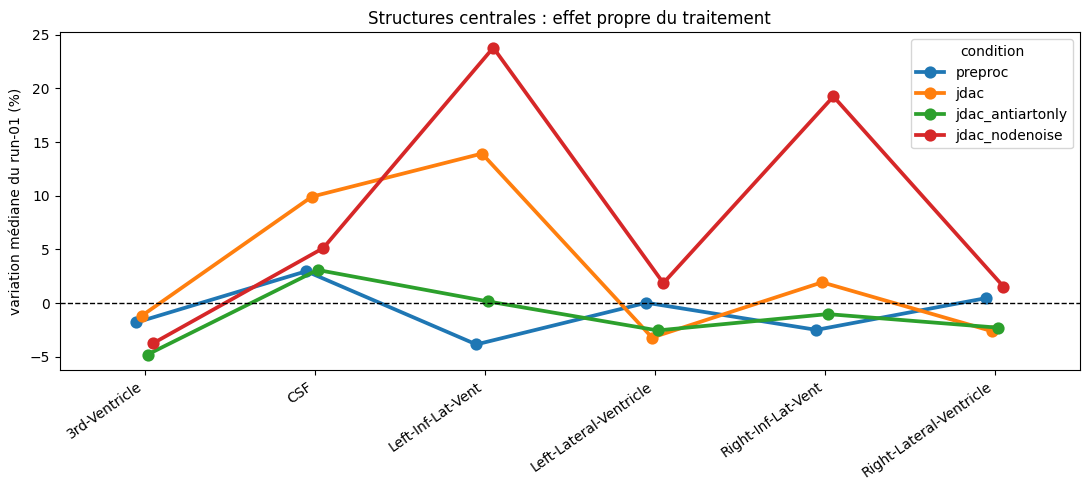

In [6]:
central = [
    "3rd-Ventricle", "Left-Thalamus-Proper", "Right-Thalamus-Proper",
    "Left-Lateral-Ventricle", "Right-Lateral-Ventricle",
    "Left-Inf-Lat-Vent", "Right-Inf-Lat-Vent", "CSF"
]
central_a = a[a["measure"].isin(central)].copy()
display(central_a.sort_values(["measure","condition"]))
if len(central_a):
    plt.figure(figsize=(11, 5))
    sns.pointplot(data=central_a, x="measure", y="delta_median_pct",
                  hue="condition", dodge=True)
    plt.axhline(0, color="black", ls="--", lw=1)
    plt.ylabel("variation médiane du run-01 (%)")
    plt.xlabel(""); plt.xticks(rotation=35, ha="right")
    plt.title("Structures centrales : effet propre du traitement")
    plt.tight_layout(); plt.show()

## Conclusion à remplir après exécution

- **Stabilité du run-01 :** quelles structures sont modifiées sans mouvement ?
- **Récupération :** quelles conditions rapprochent réellement les runs bougés de la référence ?
- **Mouvement résiduel :** quelles mesures restent associées à Agitation après FDR ?
- **Zone centrale :** le changement est-il un contraste visuel, un volume différent ou un label différent ?

Aucune amélioration globale ne sera appelée « restauration anatomique » sans cohérence entre ces quatre lectures.